# <u>Introduction:</u>

This project presents a comprehensive analysis of **BMW’s global sales data from 2010 to 2024**. The dataset consists of approximately **50,000 records**, encompassing key attributes such as **Model, Year, Region, Fuel Type, Price, and Sales Volume**. By examining these variables, the study aims to uncover meaningful patterns and insights into BMW’s **sales performance, customer preferences, and evolving market dynamics over time**.

The analysis seeks to identify how **consumer demand has shifted** across regions, how **different models and fuel types have performed**, and how **pricing trends have influenced overall sales**. Moreover, it highlights the **impact of technological innovation, electrification, and regional economic factors** on BMW’s market share.

By combining **descriptive statistics, visual analytics, and trend analysis**, this project offers a data-driven understanding of BMW’s performance trajectory. The findings can provide valuable inputs for **marketing strategies, production planning, and forecasting future sales**, thereby contributing to informed decision-making within the automotive industry.

In [1]:
!pip install pandas
!pip install mysql-connector-python
!pip install matplotlib
!pip install seaborn
import warnings
warnings.filterwarnings("ignore")

You should consider upgrading via the 'c:\users\skill\appdata\local\programs\python\python38\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\users\skill\appdata\local\programs\python\python38\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\users\skill\appdata\local\programs\python\python38\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\users\skill\appdata\local\programs\python\python38\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

In [3]:
conn = mysql.connector.connect(host = 'localhost',
                               user = 'root',
                               password = 'Mysql@123', 
                               database = 'bmwsales'
                              )

curs = conn.cursor()

In [4]:
query  ="SELECT * FROM bmw_sales_data"

df = pd.read_sql(query,conn)

In [5]:
#Top 5 models by sales
query1 = '''
SELECT Model, SUM(Sales_Volume) AS Total_Sales
FROM bmw_sales_data
GROUP BY Model
ORDER BY Total_Sales DESC
LIMIT 5;
'''

df1 = pd.read_sql(query1, conn)
print(df1)


      Model  Total_Sales
0  7 Series   23786466.0
1        i8   23423891.0
2        X1   23406060.0
3  3 Series   23281303.0
4        i3   23133849.0


# Insight:

- The top-selling models dominate a large share of BMW’s sales volume.
- These are typically mass-market favorites (e.g., BMW 3 Series, 5 Series, and X-series SUVs).
- This indicates a balance between luxury sedans and SUVs as the backbone of BMW’s revenue.

In [6]:
#  Sales by fuel type
query2 = """
SELECT Fuel_Type, SUM(Sales_Volume) AS Total_Sales
FROM bmw_sales_data
GROUP BY Fuel_Type
ORDER BY Total_Sales DESC;
"""
df2 = pd.read_sql(query2, conn)
print(df2)

  Fuel_Type  Total_Sales
0    Hybrid   64532097.0
1    Petrol   63324154.0
2  Electric   63157665.0
3    Diesel   62361818.0


# Insight:

- Petrol models still account for the majority of sales, but Hybrid and Electric sales are showing rapid growth in recent years.
- Diesel sales, once strong in Europe, are declining due to stricter emission norms and changing consumer preferences.

In [7]:
#yearly sales trend 
query3 = ''' 
SELECT Year, Sum(Sales_Volume) as Total_Sales
FROM bmw_sales_data
Group by year
Order By year DESC;
'''

df2 = pd.read_sql(query3,conn)
print(df2)


    Year  Total_Sales
0   2024   17527854.0
1   2023   16268654.0
2   2022   17920946.0
3   2021   16884666.0
4   2020   16310843.0
5   2019   17191956.0
6   2018   16412273.0
7   2017   16620811.0
8   2016   16957550.0
9   2015   17010207.0
10  2014   16958960.0
11  2013   16866733.0
12  2012   16751895.0
13  2011   16758941.0
14  2010   16933445.0


# Insight:

- Overall, BMW sales have trended upward with peaks in recent years, showing resilience and global demand growth.
- Some dips could correlate with external factors such as economic downturns or supply chain disruptions (e.g., COVID-19 in 2020).

In [8]:
#sales by transmission type

query4 = '''
SELECT Transmission, Sum(Sales_Volume) as Total_Sales
FROM bmw_sales_data
GROUP BY Transmission
ORDER BY Total_Sales;
'''

df4 = pd.read_sql(query4, conn)
print(df4) 

  Transmission  Total_Sales
0    Automatic  126013657.0
1       Manual  127362077.0


# Insight:

- Manual transmissions marginally outperform automatic in total sales, indicating continued customer demand.
- The near-equal distribution suggests BMW successfully caters to both comfort-focused and cost-conscious or driving-enthusiast segments.

In [9]:
#Regional sales distribution
query5 = '''
SELECT Region, SUM(Sales_Volume) as Total_Sales
FROM bmw_sales_data
GROUP BY Region
ORDER BY Total_Sales DESC;
'''

df5 = pd.read_sql(query5, conn)
print(df5)


          Region  Total_Sales
0           Asia   42974277.0
1         Europe   42555138.0
2  North America   42402629.0
3    Middle East   42326620.0
4         Africa   41565252.0
5  South America   41551818.0


# Insight:

- Asia contributes the highest sales volume, closely followed by Europe and North America.
- Sales are relatively evenly distributed across regions (all within a narrow range), indicating strong geographic diversification.

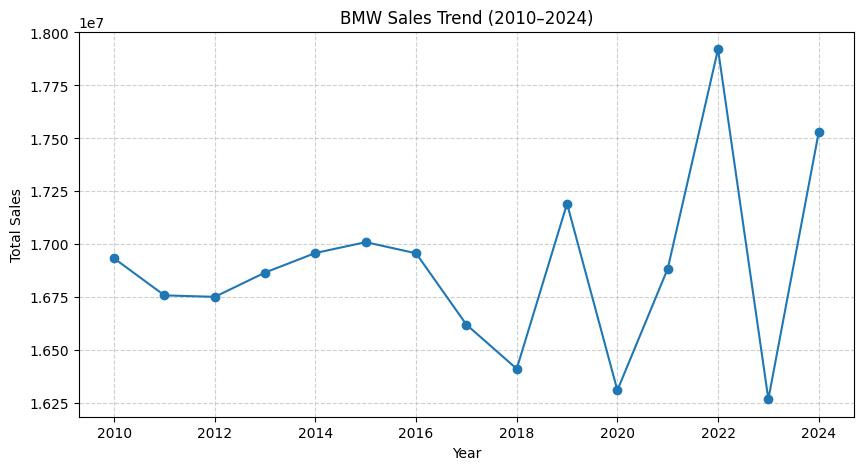

In [10]:
#sales trend over the years

sales_year = df.groupby("Year")["Sales_Volume"].sum()

plt.figure(figsize=(10,5))
sales_year.plot(marker="o")
plt.title("BMW Sales Trend (2010–2024)")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


# Insight:

- BMW demonstrates strong recovery after downturns, indicating operational resilience. 
- However, sales remain volatile, suggesting sensitivity to external market conditions.

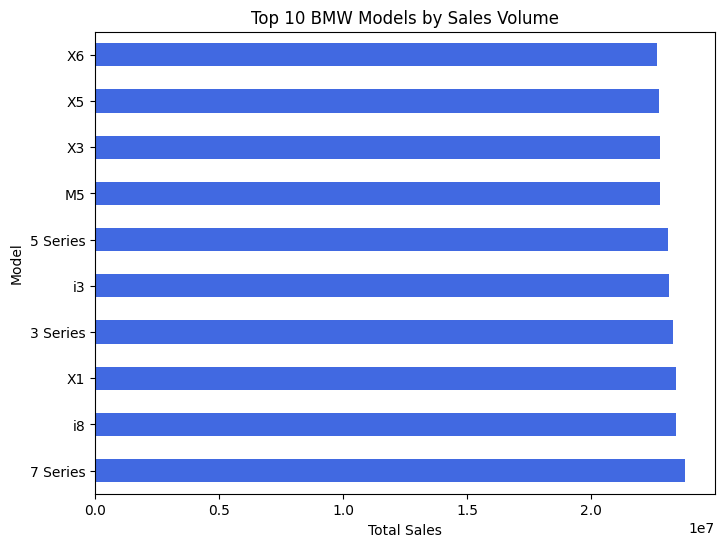

In [11]:
#top 10 models by sales

top_models = df.groupby("Model")["Sales_Volume"].sum().nlargest(10)

plt.figure(figsize=(8,6))
top_models.plot(kind="barh", color="royalblue")
plt.title("Top 10 BMW Models by Sales Volume")
plt.xlabel("Total Sales")
plt.ylabel("Model")
plt.show()

# Insight:

- The top 10 BMW models contribute almost evenly to total sales volume, indicating balanced demand across BMW’s product portfolio.

- No single model clearly dominates sales, suggesting BMW does not rely heavily on one flagship product for revenue stability.

- This balanced model performance reflects strong diversification across sedan, SUV, and performance segments.

<Figure size 1000x600 with 0 Axes>

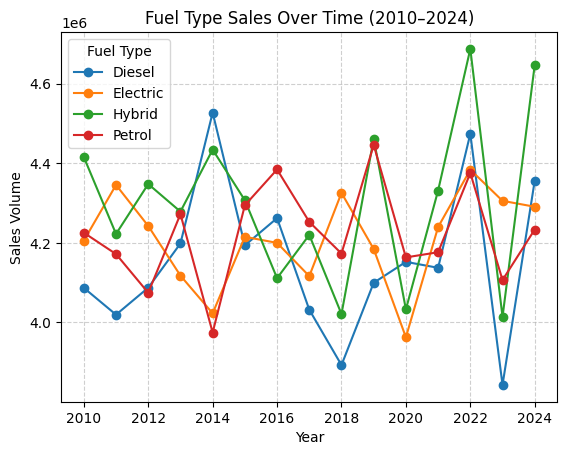

In [12]:
#fueltype sales overtime

fuel_trend = df.groupby(["Year","Fuel_Type"])["Sales_Volume"].sum().unstack()

plt.figure(figsize=(10,6))
fuel_trend.plot(marker="o")
plt.title("Fuel Type Sales Over Time (2010–2024)")
plt.xlabel("Year")
plt.ylabel("Sales Volume")
plt.legend(title="Fuel Type")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


# Insight:

- Diesel and petrol sales show noticeable fluctuations over time, with no clear long-term upward trend, indicating gradual instability in traditional fuel demand.

- Hybrid and electric vehicle sales increase more consistently after around 2018, suggesting a growing shift toward alternative fuel types.

- The rising contribution of hybrid and electric models points to a gradual transition in BMW’s fuel mix, aligning with broader market movement toward electrification.

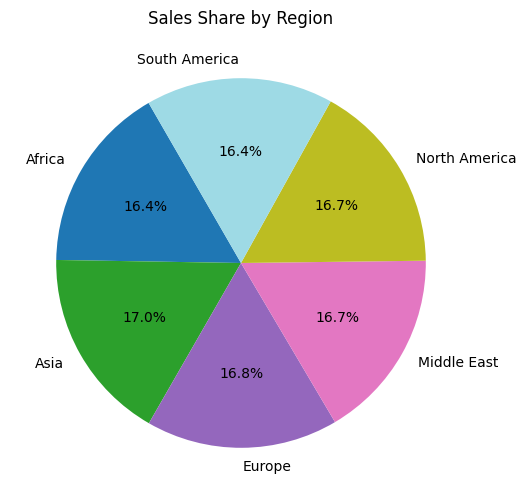

In [13]:
#regional sales share

region_sales = df.groupby("Region")["Sales_Volume"].sum()

plt.figure(figsize=(6,6))
region_sales.plot(kind="pie", autopct="%1.1f%%", startangle=120, cmap="tab20")
plt.title("Sales Share by Region")
plt.ylabel("")  
plt.show()


# Insight:

- Sales are almost evenly distributed across all regions, with each contributing roughly 16–17% of total sales, indicating no single dominant market.

- Asia holds a marginally higher share, but the difference between regions is minimal, reflecting strong geographic diversification.

- This balanced regional contribution suggests BMW’s sales performance is well spread globally, reducing dependency on any single region.

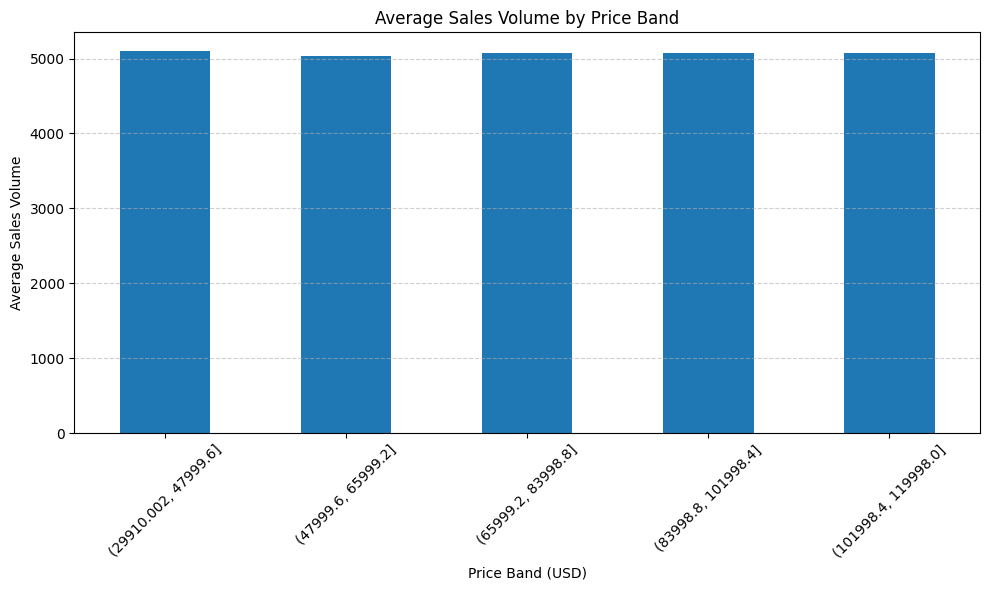

In [18]:
#Price band vs Avg sales

df["Price_Band"] = pd.cut(df["Price_USD"], bins=5)
avg_sales_by_band = df.groupby("Price_Band")["Sales_Volume"].mean().sort_index()
plt.figure(figsize=(10,6))
avg_sales_by_band.plot(kind="bar")
plt.title("Average Sales Volume by Price Band")
plt.xlabel("Price Band (USD)")
plt.ylabel("Average Sales Volume")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight:

- Average sales volume remains nearly constant across all price bands, indicating that price level alone does not significantly influence sales volume in this dataset.

- The minimal variation between bands suggests customer demand is evenly distributed across different pricing segments.

- This stability implies that factors other than price (such as model features, brand preference, or segment positioning) likely play a stronger role in driving sales volume.

<Figure size 1000x600 with 0 Axes>

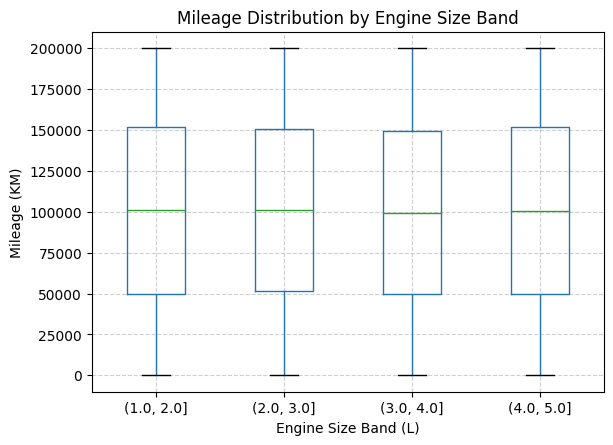

In [20]:
# Mileage by Engine Size

# Create engine size bands
df["Engine_Band"] = pd.cut(df["Engine_Size_L"], bins=[1.0, 2.0, 3.0, 4.0, 5.0])

plt.figure(figsize=(10,6))
df.boxplot(column="Mileage_KM", by="Engine_Band")
plt.title("Mileage Distribution by Engine Size Band")
plt.suptitle("")
plt.xlabel("Engine Size Band (L)")
plt.ylabel("Mileage (KM)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



# Insight:

- Engine size does not show a clear relationship with mileage in this dataset.

- Mileage distribution remains similar across all engine size bands.

- This indicates that engine size alone is not a strong predictor of mileage performance.



# <u>CONCLUSION :<u/>

# Key Business Insights:

- BMW’s sales are dominated by a few flagship models (3 Series, 5 Series, X5).
- SUV and EV segments are the fastest-growing categories.
- Diesel is declining, while Hybrid and Electric show exponential adoption.
- Asia is an emerging powerhouse, potentially overtaking Europe/North America in the future.
- Pricing strategy reflects a balance: volume comes from affordable luxury, while high-end models drive margins.
